In [7]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [8]:
from figures_setup import *
from utils import set_color_code

# MDO-derived tumors VAKPS and VKPN

## Getting data from arrayExpress: E-MTAB-16835

In [9]:
# Download data from arrayExpress and reassemble anndata object 
from utils_arrayExpress import get_public_study_adata

accession = "E-MTAB-16835"
download_dir = '../data_arrayExpress'
adata = get_public_study_adata(
    accession=accession,
    download_dir=download_dir,
    dataset = 'epi',
)
adata

[setup] Download directory: ../data_arrayExpress
[1/3] Found existing files for E-MTAB-16835 in: ../data_arrayExpress/E-MTAB-16835
      force_download=False -> skipping download.
[2/3] Inferring dataset structure in: ../data_arrayExpress/E-MTAB-16835
      Inferred 2 dataset representations:
      - epi (full prefix: AKPS_KPN_epi)
      - full (full prefix: AKPS_KPN_full)
      Selected dataset for in-memory loading: epi (full prefix: AKPS_KPN_epi)
[3/3] Multiple datasets detected.
      Saving all inferred datasets to disk; loading only one into memory.
      Already exists, skipping rebuild: E-MTAB-16835/E-MTAB-16835_epi.h5ad
      Already exists, skipping rebuild: E-MTAB-16835/E-MTAB-16835_full.h5ad
      Loading selected dataset from disk: E-MTAB-16835/E-MTAB-16835_epi.h5ad


AnnData object with n_obs × n_vars = 1573 × 18791
    obs: 'sample_id', 'library_id', 'line', 'replicate', 'leiden', 'HTO_classification', 'HTO_classification.global', 'HTO_maxID'
    uns: 'dataset_prefix', 'source_files', 'loaded_from_h5ad'
    obsm: 'X_umap'
    layers: 'counts', 'log1p'

## UMAP representation

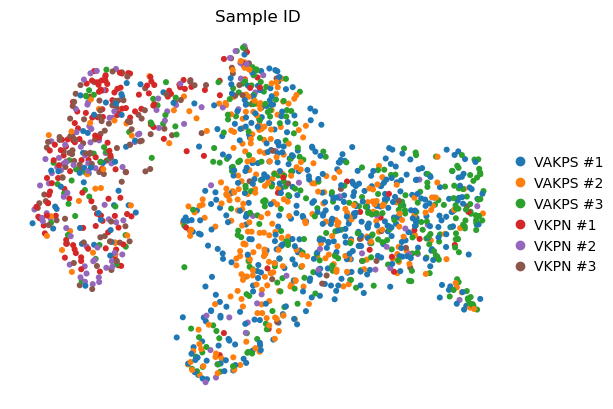

In [10]:
# Sample ID UMAP

# Get short sample IDs
sample_id_dict = {
    'AKPS_NV16_4': 'VAKPS #1',
    'AKPS_NV16_5': 'VAKPS #2',
    'AKPS_NV16_6': 'VAKPS #3',
    'KPN_NV14_1': 'VKPN #1',
    'KPN_NV14_2': 'VKPN #2',
    'KPN_NV14_3': 'VKPN #3',
}
adata.obs['sample_id_short'] = adata.obs['sample_id'].map(sample_id_dict)

# Plot UMAP
sc.pl.umap(
    adata, 
    color='sample_id_short', 
    frameon=False, 
    title='Sample ID',
)

## Marker gene distribution

dict_keys(['mainplot_ax', 'gene_group_ax', 'size_legend_ax', 'color_legend_ax'])


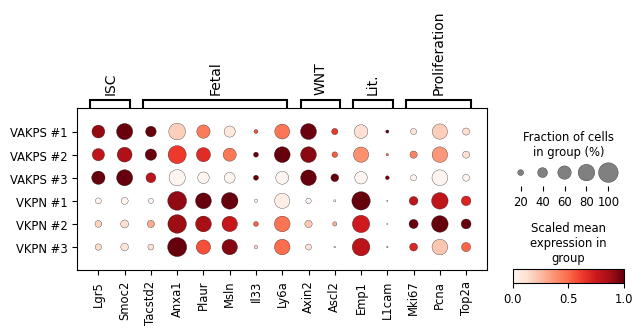

In [11]:
# Make dotplot over feature
marker_genes_dict = {
    "ISC": ["Lgr5", "Smoc2"],
    "Fetal": ["Tacstd2", "Anxa1", "Plaur", "Msln", "Il33", "Ly6a"],
    "WNT": ["Axin2", "Ascl2"],
    "Lit.": ["Emp1", "L1cam"],
    "Proliferation": ["Mki67", "Pcna", "Top2a"],
}

# Set order sample_id_short values
adata.obs['sample_id_short'] = pd.Categorical(
    adata.obs['sample_id_short'],
    categories=['VAKPS #1', 'VAKPS #2', 'VAKPS #3', 'VKPN #1', 'VKPN #2', 'VKPN #3'],
    ordered=True
)

# Make the dot plot
dp = sc.pl.dotplot(
    adata,
    marker_genes_dict,
    groupby="sample_id_short",
    standard_scale="var",
    swap_axes=False,
    return_fig=True,
)
dp.legend(
    width=1.5,
    colorbar_title="Scaled mean\nexpression in\ngroup",
)

dp.make_figure()

# Check available axes names if needed
print(dp.ax_dict.keys())

# Move the colorbar legend downward
color_ax = dp.ax_dict["color_legend_ax"]
pos = color_ax.get_position()
color_ax.set_position([
    pos.x0,
    pos.y0 - 0.04,   # increase this for more vertical space
    pos.width,
    pos.height,
])

## Gene set enrichment TROP2+ vs TROP2- 

In [12]:
import decoupler as dc
dc.__version__

'2.0.6'

### Pseudobulk generation

In [13]:
adata.obs['sample_id'].value_counts()

sample_id
AKPS_NV16_4    488
AKPS_NV16_6    339
AKPS_NV16_5    332
KPN_NV14_1     164
KPN_NV14_3     127
KPN_NV14_2     123
Name: count, dtype: int64

In [14]:
# Add Lgr5 / Trop2 status
from utils import add_SC_status
adata = add_SC_status(adata, species="Mm")

In [15]:
# Add TROP2 status column based on 'TROP2_pos' boolean column
adata.obs['TROP2_status'] = ['Trop2_pos' if x else 'Trop2_neg' for x in adata.obs['Tacstd2_pos']]
adata.obs['TROP2_status'].value_counts()

TROP2_status
Trop2_neg    979
Trop2_pos    594
Name: count, dtype: int64

In [16]:
### Generate pseudobulks

### Compute pseudobulk profiles
sample_col = 'sample_id'
group_col = 'TROP2_status'
min_cells = 10

pdata = dc.pp.pseudobulk(
    adata,
    sample_col=sample_col,
    groups_col=group_col,
    layer='counts',
    mode='sum',
)

### Filter for minimum number of cells
# Count cells in original single-cell AnnData
cell_counts = adata.obs.groupby([sample_col, group_col]).size()
# Keep only sample-group combinations with enough cells
valid_combinations = set(cell_counts[cell_counts >= min_cells].index)
# print(f"Valid samples: {valid_combinations}") ### tbc: remove line
# Build tuples from pdata.obs
pdata_combinations = list(zip(pdata.obs[sample_col], pdata.obs[group_col]))
# Filter pdata
pdata = pdata[[comb in valid_combinations for comb in pdata_combinations]].copy()

/tmp/ipykernel_4147766/2238731965.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cell_counts = adata.obs.groupby([sample_col, group_col]).size()


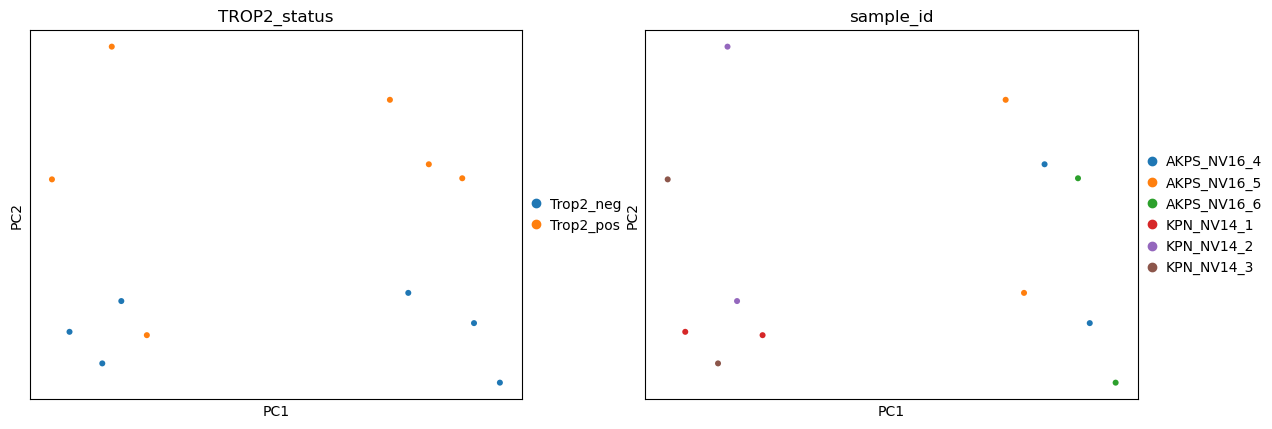

In [17]:
### Compute PCA on pseudobulk data
# Store raw counts in layers
pdata.layers['counts'] = pdata.X.copy()

# Normalize, scale and compute pca
sc.pp.normalize_total(pdata, target_sum=1e4)
sc.pp.log1p(pdata)
sc.pp.scale(pdata, max_value=10)
sc.tl.pca(pdata)

# Return raw counts to X
dc.pp.swap_layer(pdata, key='counts', inplace=True)


### Visualize data on PCA
# Not part of manuscript
fig = sc.pl.pca(pdata, color=[group_col, sample_col], ncols=2, size=75, show=False, return_fig=True)
fig.show()

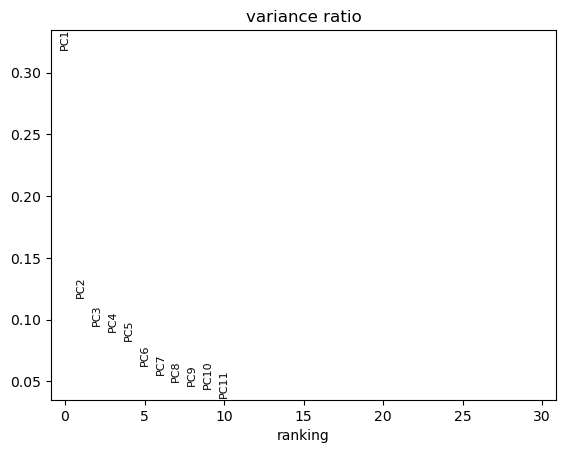

In [18]:
### Plot variance explained by PCs
# Not part of manuscript
sc.pl.pca_variance_ratio(pdata)

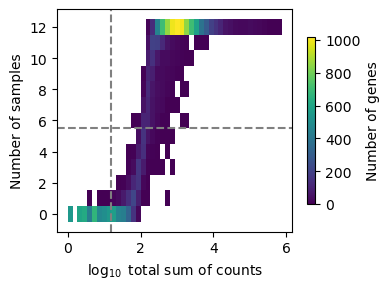

In [19]:
### Filter by expression
min_count = 10
min_total_count = 15
dc.pl.filter_by_expr(
    adata=pdata,
    group=group_col,
    min_count=min_count,
    min_total_count=min_total_count,
)
dc.pp.filter_by_expr(
    pdata, 
    group=sample_col, 
    min_count=min_count, 
    min_total_count=min_total_count
)

In [20]:
### Save pseudobulk data
pdata.write_h5ad(os.path.join(dir_data, f"{accession}_pdata.h5ad"))
pdata

AnnData object with n_obs × n_vars = 12 × 11910
    obs: 'sample_id', 'TROP2_status', 'library_id', 'line', 'replicate', 'HTO_classification', 'HTO_classification.global', 'HTO_maxID', 'sample_id_short', 'Tacstd2_pos', 'psbulk_cells', 'psbulk_counts'
    var: 'mean', 'std'
    uns: 'log1p', 'pca', 'TROP2_status_colors', 'sample_id_colors'
    obsm: 'X_pca'
    varm: 'PCs'
    layers: 'psbulk_props', 'counts', 'X'

### DGEA on pseudobulks

In [21]:
import decoupler as dc

# # Read pseudobulk data
# accession = "E-MTAB-16835"
# pdata = sc.read_h5ad(os.path.join(dir_data, f"{accession}_pdata.h5ad"))

In [22]:
# Import DESeq2
from pydeseq2.dds import DeseqDataSet, DefaultInference
from pydeseq2.ds import DeseqStats

In [23]:
# Split datasets by line
pdata_vakps = pdata[pdata.obs['line'] == 'AKPS'].copy()
pdata_vkpn = pdata[pdata.obs['line'] == 'KPN'].copy()
del pdata

In [24]:
# Aggregate results in dictionary
res_dgea = {}

#### DGEA on VAKPS line

In [25]:
pdata = pdata_vakps.copy()

In [26]:
# Set up DGEA comparison
design = 'TROP2_status'
design_ref = 'Trop2_neg'

In [27]:
# Create DESeq2 object
inference = DefaultInference(n_cpus=8)
dds = DeseqDataSet(
    adata=pdata,
    design_factors=design,
    ref_level=[design, design_ref],
    refit_cooks=True,
    inference=inference,
)

/tmp/ipykernel_4147766/2903302091.py:3: UserWarning: Same factor names in the design contain underscores ('_'). They will
                be converted to hyphens ('-').
  dds = DeseqDataSet(
/omics/groups/OE0285/internal/puschhof/envs/env_funcomics/lib/python3.10/site-packages/pydeseq2/dds.py:264: UserWarning: Some factor levels in the design contain underscores ('_').
                    They will be converted to hyphens ('-').
  self.obsm["design_matrix"] = build_design_matrix(


In [28]:
# Dispersion and LFC estimation 
dds.deseq2()

Fitting size factors...
... done in 0.00 seconds.

Fitting dispersions...
... done in 1.36 seconds.

Fitting dispersion trend curve...
... done in 3.39 seconds.

Fitting MAP dispersions...
... done in 1.55 seconds.

Fitting LFCs...
... done in 1.04 seconds.

Calculating cook's distance...
... done in 0.01 seconds.

Replacing 0 outlier genes.



In [29]:
### Contrast between conditions

# Replace design underscores with dashes for DeseqStats compatibility
design = design.replace("_", "-")
design_ref = design_ref.replace("_", "-")

### Contrast between conditions
cond = 'Trop2-pos'
print(f"Contrasting with test condition {cond}")
stat_res = DeseqStats(
    dds,
    contrast=[design, cond, design_ref],
    inference=inference,
)
# Compute and depict Wald test results
stat_res.summary()

# Extract results
results_df = stat_res.results_df
results_df.insert(0, 'contrast', f'{cond}_vs_{design_ref}')
results_df.to_csv(f'../data_suppl/{accession}_Ext_Fig_02f-g_pbulk_DGEA_results.csv')
print(f"Number of DE genes with padj < 0.05: {results_df[results_df['padj'] < 0.05].shape[0]}")

# Save results in dictionary
res_dgea['AKPS'] = results_df

Running Wald tests...


Contrasting with test condition Trop2-pos


... done in 0.61 seconds.



Log2 fold change & Wald test p-value: TROP2-status Trop2-pos vs Trop2-neg
                 baseMean  log2FoldChange     lfcSE      stat    pvalue  \
feature                                                                   
Mrpl39         101.218312        0.356789  0.240701  1.482293  0.138262   
Ube2q1         201.472519        0.085489  0.161109  0.530627  0.595678   
Marcks         366.826444       -0.182877  0.190583 -0.959567  0.337273   
Rarb            13.078387        0.241554  0.657711  0.367265  0.713421   
Med11           71.650437        0.278755  0.272643  1.022416  0.306584   
...                   ...             ...       ...       ...       ...   
4930563E22Rik    7.237119       -1.105915  0.731260 -1.512343  0.130447   
Shroom3         82.701681        0.261021  0.277006  0.942293  0.346043   
Pola1           88.263218        0.165128  0.260337  0.634284  0.525895   
Adgrf5          37.200924       -1.101962  0.328078 -3.358842  0.000783   
Lst1            28.801078 

Plotting results as volcano plot


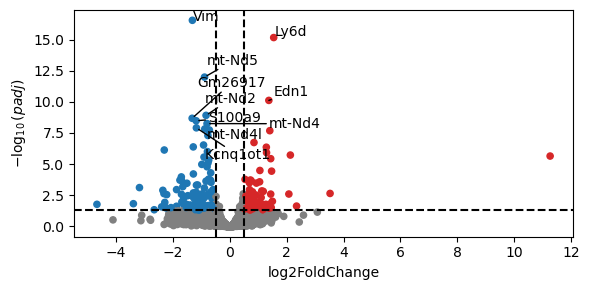

In [30]:
### Plot volcano plot
# Not part of manuscript
print("Plotting results as volcano plot")
dc.pl.volcano(
    results_df,
    x='log2FoldChange',
    y='padj',
    top=10,
    figsize=(6, 3),
)

#### DGEA on VKPN line

In [31]:
pdata = pdata_vkpn.copy()

In [32]:
# Set up DGEA comparison
design = 'TROP2_status'
design_ref = 'Trop2_neg'

In [33]:
# Create DESeq2 object
inference = DefaultInference(n_cpus=8)
dds = DeseqDataSet(
    adata=pdata,
    design_factors=design,
    ref_level=[design, design_ref],
    refit_cooks=True,
    inference=inference,
)

/tmp/ipykernel_4147766/2903302091.py:3: UserWarning: Same factor names in the design contain underscores ('_'). They will
                be converted to hyphens ('-').
  dds = DeseqDataSet(
/omics/groups/OE0285/internal/puschhof/envs/env_funcomics/lib/python3.10/site-packages/pydeseq2/dds.py:264: UserWarning: Some factor levels in the design contain underscores ('_').
                    They will be converted to hyphens ('-').
  self.obsm["design_matrix"] = build_design_matrix(


In [34]:
# Dispersion and LFC estimation 
dds.deseq2()

Fitting size factors...
... done in 0.00 seconds.

Fitting dispersions...
... done in 1.34 seconds.

Fitting dispersion trend curve...
... done in 1.96 seconds.

Fitting MAP dispersions...
... done in 1.48 seconds.

Fitting LFCs...
... done in 1.12 seconds.

Calculating cook's distance...
... done in 0.01 seconds.

Replacing 0 outlier genes.



In [35]:
### Contrast between conditions

# Replace design underscores with dashes for DeseqStats compatibility
design = design.replace("_", "-")
design_ref = design_ref.replace("_", "-")

### Contrast between conditions
cond = 'Trop2-pos'
print(f"Contrasting with test condition {cond}")
stat_res = DeseqStats(
    dds,
    contrast=[design, cond, design_ref],
    inference=inference,
)
# Compute and depict Wald test results
stat_res.summary()

# Extract results
results_df = stat_res.results_df
results_df.insert(0, 'contrast', f'{cond}_vs_{design_ref}')
results_df.to_csv(f'../data_suppl/{accession}_Ext_Fig_02f-g_pbulk_DGEA_results.csv')
print(f"Number of DE genes with padj < 0.05: {results_df[results_df['padj'] < 0.05].shape[0]}")

# Save results in dictionary
res_dgea['KPN'] = results_df

Running Wald tests...


Contrasting with test condition Trop2-pos


... done in 0.56 seconds.



Log2 fold change & Wald test p-value: TROP2-status Trop2-pos vs Trop2-neg
                 baseMean  log2FoldChange     lfcSE      stat    pvalue  \
feature                                                                   
Mrpl39          35.869209        0.530726  0.337525  1.572405  0.115857   
Ube2q1          52.183127        0.310754  0.269144  1.154603  0.248253   
Marcks         273.209385       -0.226848  0.168484 -1.346413  0.178169   
Rarb             1.372708        1.563308  1.709846  0.914298  0.360561   
Med11           28.569442        0.034144  0.352804  0.096779  0.922902   
...                   ...             ...       ...       ...       ...   
4930563E22Rik    3.890464       -0.130333  1.002603 -0.129995  0.896571   
Shroom3         26.608578       -0.327119  0.379524 -0.861918  0.388732   
Pola1           39.000492       -0.243039  0.317319 -0.765915  0.443727   
Adgrf5          51.910187       -0.208589  0.304521 -0.684973  0.493361   
Lst1            11.524411 

Plotting results as volcano plot


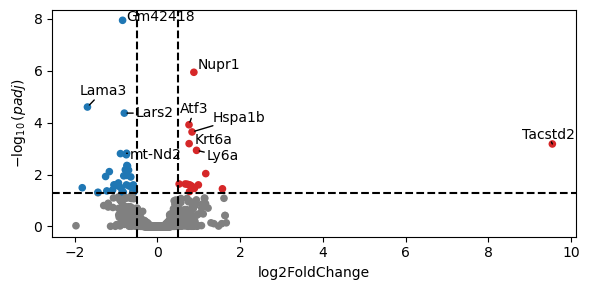

In [36]:
### Plot volcano plot
# Not part of manuscript
print("Plotting results as volcano plot")
dc.pl.volcano(
    results_df,
    x='log2FoldChange',
    y='padj',
    top=10,
    figsize=(6, 3),
)

### Enrichment of custom gene sets

In [37]:
# Import literature gene sets to adata.uns
from utils_VAKPS_VKPN import get_gene_sets
print("Importing gene sets into anndata object...")
adata = get_gene_sets(adata, verbose=False)

Importing gene sets into anndata object...


### Define anxillary functions

In [38]:
# Define section-specific functions

def get_anndata_from_file(data_path=None, filename=None,
                          df=None,
                          stat_key='stat',
                          feature_key='names'):
    """
    Read anndata object from file.
    
    Args:
        data_path: path to data file
        filename: name of data file
        
    Returns:
        adata: anndata object
    """

    # Test if input data is provided
    if df is None and not os.path.exists(os.path.join(data_path, filename)):
        raise ValueError("Input data not correctly defined. Provide dataframe or input file.")

    # Read data from file if required
    if df is None:
        if not os.path.exists(os.path.join(data_path, filename)):
            raise ValueError(f"File not found: {filename}")
        if filename.endswith(".h5ad"):
            adata = sc.read_h5ad(os.path.join(data_path, filename))
            if adata.raw is None:
                if 'normalized' in adata.layers.keys():
                    print("Set raw to normalized")
                    adata.raw = adata.layers['normalized'].copy()
        elif filename.endswith(".pkl"):
            df = pd.read_pickle(os.path.join(data_path, filename))
            # Convert to Anndata object
            adata = anndata.AnnData(df)
            adata.obs['contrast'] = df.index  # Adds the comparison labels as metadata in obs
            adata.var_names = df.T.index
            adata.raw = adata
        elif filename.endswith(".csv"):
            df = pd.read_csv(os.path.join(data_path, filename))
            # Rename columns if applicable
            if stat_key not in df.columns and 'scores' in df.columns:
                print(f"Rename column 'scores' to {stat_key}")
                df.rename(columns={'scores': stat_key}, inplace=True)
        else:
            raise ValueError(f"File format not implemented: {filename}")

    ### Construct adata from DGEA result if needed
    print('Construct adata from DGEA results')
    if 'contrast' not in df.columns:
        if 'group' in df.columns:
            df['contrast'] = [f"{g}-vs-rest" for g in df['group']]
        else:
            df['contrast'] = 'test_vs_ref'
    elif 'group' in df.columns:
        df['contrast'] = [f"{g}-vs-all" for g in df['group']]
        
    # Turn into score matrix
    df_pivot = df.pivot(index='contrast', columns=feature_key, values=stat_key)
    adata = anndata.AnnData(
        X=df_pivot.values,
        obs=pd.DataFrame(index=df_pivot.index),
        var=pd.DataFrame(index=df_pivot.columns),
    )

    # Set nan to zero
    adata.X[np.isnan(adata.X)] = 0

    adata.raw = adata

    return adata


# Get df from enrichment results
def get_enrichment_from_adata(acts, contrast = 'contrast', name = 'source'):
        
    ''' Turn anndata object acts into pandas DataFrame with activities and p-values.'''

    # Create data frame from acts.obsm['estimate']
    act_df = pd.DataFrame(acts.X, columns=acts.var_names, index=acts.obs_names)   
    act_df = act_df.reset_index().melt(id_vars=contrast, var_name='source', value_name='acts')

    # Create data frame from acts.obsm['padj']
    key = [key for key in acts.obsm.keys() if key.startswith('padj')][0]
    pval_df = pd.DataFrame(acts.obsm[key].values, columns=acts.var_names, index=acts.obs_names)
    pval_df = pval_df.reset_index().melt(id_vars=contrast, var_name='source', value_name='padj')

    # Merge df and pval_df
    df = pd.merge(act_df, pval_df, on=[contrast, name])
    return df

#### GSEA on VAKPS line

In [39]:
# Load VAKPS results
line = 'AKPS'
res_dgea[line].head(2)
pdata = pdata_vakps.copy()

In [40]:
# Get anndata object from DGEA results
res_dgea[line].reset_index(inplace=True)
ad_dgea = get_anndata_from_file(
    df=res_dgea[line],
    stat_key = 'stat', 
    feature_key = 'feature'
)

Construct adata from DGEA results


In [41]:
# Extract gene set collection from anndata object
print(f"Extract custom gene sets from adata.uns slot")
net = adata.uns['gene_sets']

# Perform network check
import utils_genelist as genelist
net = genelist.pre_network_checks(
    net = net, 
    var_names = pdata.var_names, 
    source='gene_set' if 'gene_set' in net.columns else 'source', 
    target='gene' if 'gene' in net.columns else 'target', 
    weight='weight',
)
net.head(2)

Extract custom gene sets from adata.uns slot


,source,target,weight
0,score_fetal,Rab11fip5,1
1,score_fetal,Krt7,1


In [42]:
# Run GSEA
dc.mt.gsea(
    data = ad_dgea,
    net = net,
)

# Get activities from anndata
acts = dc.pp.get_obsm(ad_dgea, key='score_gsea')

# Get enrichment results in df format
enr_gsea = get_enrichment_from_adata(acts, contrast = 'contrast', name = 'source')
enr_gsea.rename(columns={'acts': 'NES'}, inplace=True)
enr_gsea = enr_gsea.sort_values(by='NES', ascending=False)
enr_gsea.head(2)

,contrast,source,NES,padj
1,Trop2-pos_vs_Trop2-neg,score_fetal,2.566774,0.0
0,Trop2-pos_vs_Trop2-neg,score_Lgr5,-1.506213,0.0


In [43]:
# Change to publication names ### To be added
from utils_genelist import gs_names_for_pub
enr_gsea['source'] = enr_gsea['source'].map(gs_names_for_pub)
net['source'] = net['source'].map(gs_names_for_pub)

In [44]:
# Transform enr_gsea to df and save
enr_gsea.to_csv(f"../data_suppl/{accession}_dc2_Ext_Fig_02f_results_gsea_ext.csv")
enr_gsea

,contrast,source,NES,padj
1,Trop2-pos_vs_Trop2-neg,Fetal (Mustata et al.),2.566774,0.0
0,Trop2-pos_vs_Trop2-neg,Lgr5 (Muñoz et al.),-1.506213,0.0


Enrichment plots for line VAKPS


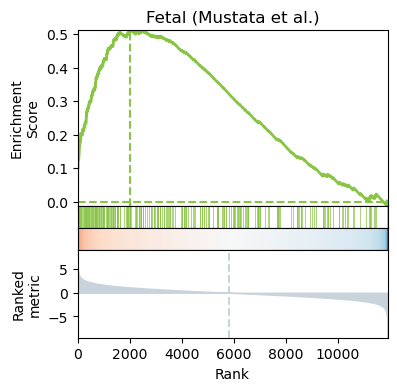

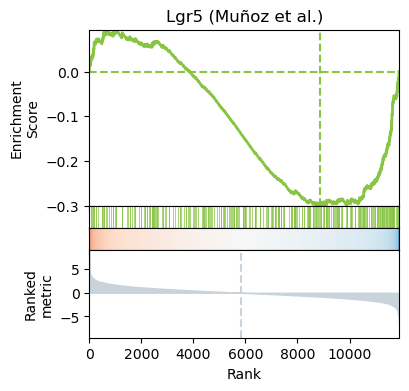

In [45]:
# Make running score plots

# Write features to index for plotting
if not res_dgea[line].index.name == 'feature':
    res_dgea[line].set_index('feature', inplace=True)

# Make running score plot
print(f"Enrichment plots for line V{line}")
scores = enr_gsea.index.tolist()
for marker in enr_gsea['source'].unique():
    dc.pl.leading_edge(
        df=res_dgea[line],
        stat='stat', 
        name=marker,
        net=net, 
        figsize=(4,4)
    )

#### GSEA on VKPN line

In [46]:
# Load VKPN results
line = 'KPN'
res_dgea[line].head(2)
pdata = pdata_vkpn.copy()

In [47]:
# Get anndata object from DGEA results
res_dgea[line].reset_index(inplace=True)
ad_dgea = get_anndata_from_file(
    df=res_dgea[line],
    stat_key = 'stat', 
    feature_key = 'feature'
)

Construct adata from DGEA results


In [48]:
# Extract gene set collection from anndata object
print(f"Extract custom gene sets from adata.uns slot")
net = adata.uns['gene_sets']

# Perform network check
import utils_genelist as genelist
net = genelist.pre_network_checks(
    net = net, 
    var_names = pdata.var_names, 
    source='gene_set' if 'gene_set' in net.columns else 'source', 
    target='gene' if 'gene' in net.columns else 'target', 
    weight='weight',
)
net.head(2)

Extract custom gene sets from adata.uns slot


,source,target,weight
0,score_fetal,Rab11fip5,1
1,score_fetal,Krt7,1


In [49]:
# Run GSEA
dc.mt.gsea(
    data = ad_dgea,
    net = net,
)

# Get activities from anndata
acts = dc.pp.get_obsm(ad_dgea, key='score_gsea')

# Get enrichment results in df format
enr_gsea = get_enrichment_from_adata(acts, contrast = 'contrast', name = 'source')
enr_gsea.rename(columns={'acts': 'NES'}, inplace=True)
enr_gsea = enr_gsea.sort_values(by='NES', ascending=False)
enr_gsea.head(2)

,contrast,source,NES,padj
1,Trop2-pos_vs_Trop2-neg,score_fetal,2.004993,0.000000
0,Trop2-pos_vs_Trop2-neg,score_Lgr5,-1.000946,0.455959


In [50]:
# Change to publication names ### To be added
from utils_genelist import gs_names_for_pub
enr_gsea['source'] = enr_gsea['source'].map(gs_names_for_pub)
net['source'] = net['source'].map(gs_names_for_pub)

In [51]:
# Transform enr_gsea to df and save
enr_gsea.to_csv(f"../data_suppl/{accession}_dc2_Ext_Fig_02g_results_gsea_ext.csv")
enr_gsea

,contrast,source,NES,padj
1,Trop2-pos_vs_Trop2-neg,Fetal (Mustata et al.),2.004993,0.000000
0,Trop2-pos_vs_Trop2-neg,Lgr5 (Muñoz et al.),-1.000946,0.455959


Enrichment plots for line VKPN


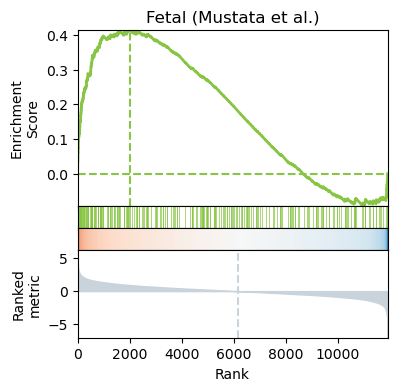

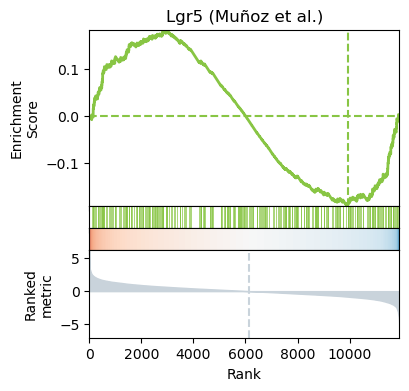

In [52]:
# Make running score plots

# Write features to index for plotting
if not res_dgea[line].index.name == 'feature':
    res_dgea[line].set_index('feature', inplace=True)

# Make running score plot
print(f"Enrichment plots for line V{line}")
scores = enr_gsea.index.tolist()
for marker in enr_gsea['source'].unique():
    dc.pl.leading_edge(
        df=res_dgea[line],
        stat='stat', 
        name=marker,
        net=net, 
        figsize=(4,4)
    )

# Session info

The analysis above has been performed using a micromamba environment with the following package versions:

In [53]:
session_info.show()

/omics/groups/OE0285/internal/puschhof/envs/env_funcomics/lib/python3.10/site-packages/session_info/main.py:213: UserWarning: The '__version__' attribute is deprecated and will be removed in MarkupSafe 3.1. Use feature detection, or `importlib.metadata.version("markupsafe")`, instead.
  mod_version = _find_version(mod.__version__)
